In [10]:
from imports import *
from information_conditions import Information_Conditions
from base_ecopg import BaseEcologicalPublicGood
from helper_functions import *
from simulation_and_results_functions import *


In [11]:
# df = pd.read_excel("../Data/Basin_of_Attraction/complete/complete_dis__0.995_m_6.5_unique_strategies_and_frequency.xlsx")


def convert_final_point_to_numpy_array(final_point, mode):
    if mode == 'complete' or mode == 'social': number_of_prosperous_states = 4
    elif mode == 'ecological' or mode == 'none': number_of_prosperous_states = 1
    flat = np.fromstring(final_point.replace('[', ' ').replace(']', ' '), sep=' ', dtype=float)
    array = flat.reshape(2, number_of_prosperous_states)
    return array



def process_and_parase_avg_cooperation_from_data(df, mode):
    df["final_point"] = df["final_point"].apply(lambda x: convert_final_point_to_numpy_array(x, mode))
    weighted_avg_coop = (df["avg_coop"] * df["frequency"]).sum()
    return weighted_avg_coop

def process_and_get_cooperative_points_frequency(df, mode):
    df["final_point"] = df["final_point"].apply(lambda x: convert_final_point_to_numpy_array(x, mode))
    cooperative_points = df[df["avg_coop"] > 0.95]
    cooperative_points_frequency = cooperative_points["frequency"].sum()
    return cooperative_points_frequency

In [12]:
m_values = [6.5]
discount_factors = [0.955, 0.965, 0.975, 0.985, 0.995]

modes = ['complete', 'ecological', 'social', 'none']  #all_information_modes[0]  #complete, social, ecological, none

for m in m_values:
        avg_cooperation_results_across_discount_factors = {}

        for d in discount_factors:
                avg_cooperation_results = {}

                for mode in modes:
                        df = pd.read_excel(f"../Data/Basin_of_Attraction/{mode}/{mode}_dis__{d}_m_{m}_unique_strategies_and_frequency.xlsx")
                        weighted_avg_coop = process_and_parase_avg_cooperation_from_data(df, mode)
                        avg_cooperation_results[mode] = weighted_avg_coop
                avg_cooperation_results_across_discount_factors[d] = avg_cooperation_results




In [13]:
m_values = [6.5]
discount_factors = [0.955, 0.965, 0.975, 0.985, 0.995]

modes = ['complete', 'ecological', 'social', 'none']  #all_information_modes[0]  #complete, social, ecological, none

for m in m_values:
        cooperative_points_frequency_results_across_discount_factors = {}

        for d in discount_factors:
                cooperative_points_frequency_results = {}

                for mode in modes:
                        df = pd.read_excel(f"../Data/Basin_of_Attraction/{mode}/{mode}_dis__{d}_m_{m}_unique_strategies_and_frequency.xlsx")
                        cooperative_points_frequency = process_and_get_cooperative_points_frequency(df, mode)
                        cooperative_points_frequency_results[mode] = cooperative_points_frequency
                cooperative_points_frequency_results_across_discount_factors[d] = cooperative_points_frequency_results




In [14]:

def make_barplots_for_cooperate_basin_size_(basin_of_attraction_cooperation_results_each_mode, discount_factor, m_value, ax = None):

    # Extract values in correct order
    cooperation_basin_size = [
        basin_of_attraction_cooperation_results_each_mode[condition]
        for condition in all_information_modes
    ]

    # Shorter labels (removed "Information")
    conditions = [
        "Complete",
        "Social",
        "Ecological",
        "No Info"
    ]

    # Colors (map still keyed by original meaning)
    color_map = {
        "Complete": "#4c72b0",   # blue
        "Social": "#FFB6C1",     # pink
        "Ecological": "#55a868", # green
        "No Info": "#000000"        # black
    }

    # Make figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(
        conditions,
        cooperation_basin_size,
        color=[color_map[c] for c in conditions]
    )

    # Add percentage labels on top
    for bar, val in zip(bars, cooperation_basin_size):
        if val > 20:
            # Place inside
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=15,
                color="white"
            )
        else:
            # Place just above
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 2,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=15,
                color="black"
            )


    # Labels
    # ax.set_ylabel("Cooperation Basin Size (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_tick_params(labelsize=18)  # ✅ Larger y-axis labels
    ax.yaxis.label.set_size(20)  # ✅ Larger y-axis title

    # ✅ Use short x-axis labels
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, fontsize=18)

    ax.grid(False)

    # Title/annotation inside top-right of the plot
    
    # ax.text(
    #     0.5, 0.85, 
    #     s =  rf"$\delta = {discount_factor}$",
    #     transform=ax.transAxes, 
    #     ha="right", va="top",
    #     fontsize=14,
    #     bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round,pad=0.3")
    # )

    #slight greyish background
    ax.set_facecolor('#f7f7f7')

    # fig.savefig(rf"C:\Users\localuser\Desktop\Social_Ecological_Info_Cooperation\Code\Plots\Thesis\Cooperation_Levels\cooperation_levels_{discount_factor}_{abs(m_value)}.png", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    # plt.show()


In [15]:
print(os.getcwd())

d:\Personal Projects\Social_Ecological_Info_Cooperation\Code\My_Simulations


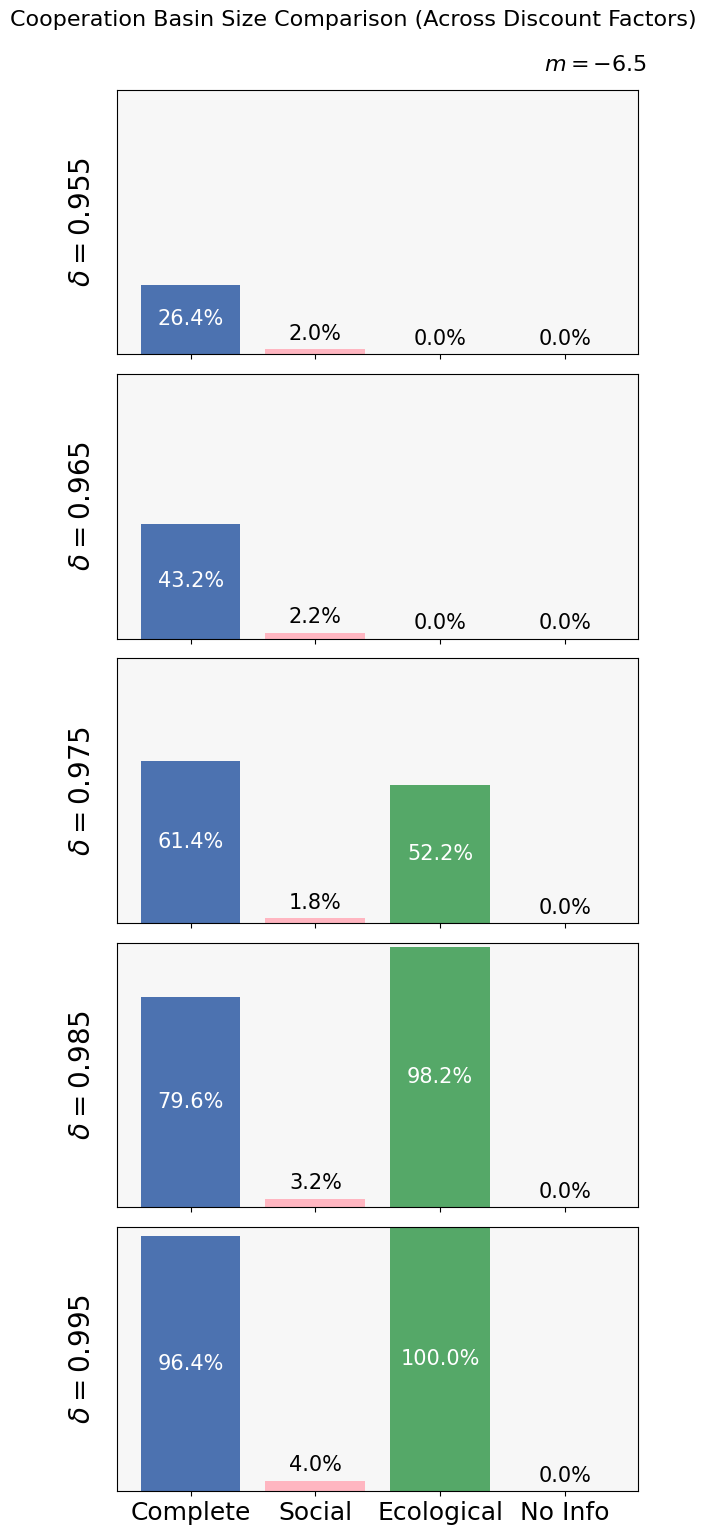

In [16]:
fig, axes = plt.subplots(len(discount_factors), 1, figsize=(6, 3*len(discount_factors)), sharex=True)
for ax, d in zip(axes, discount_factors):
        make_barplots_for_cooperate_basin_size_(cooperative_points_frequency_results_across_discount_factors[d], discount_factor=d, m_value = -6.5, ax = ax)


fig.suptitle("Cooperation Basin Size Comparison (Across Discount Factors)", fontsize=16, y=1.02)
for ax, d in zip(axes, discount_factors):
#     ax.bar([1, 2, 3], [1, 2, 3])
    ax.set_yticks([])   # remove local ticks
    ax.set_ylabel(rf"$\delta={d:.3f}$", rotation=90, labelpad=25, va="center")

m_value = -6.5
fig.text(
        0.99, 0.99, 
        s =  rf"$m = {m_value}$",
        ha="right", va="top",
        fontsize=16,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, boxstyle="round,pad=0.3")
    )

fig.tight_layout()
# fig.savefig(rf"C:\Users\localuser\Desktop\Social_Ecological_Info_Cooperation\Code\Plots\Thesis\Cooperation_Levels\cooperation_levels_across_discount_factors_common_m_{abs(m_value)}.png", dpi=300, bbox_inches="tight")
fig.savefig(rf"d:\Personal Projects\Social_Ecological_Info_Cooperation\Code\Plots\Thesis\Cooperation_Levels\cooperation_basin_size_across_discount_factors_common_m_{abs(m_value)}.png", dpi=300, bbox_inches="tight")
